## Preprocessing

#### Import libraries for preprocessing

In [1]:
import matplotlib.pyplot as plt
plt.figure(figsize=(11,11))

<Figure size 1100x1100 with 0 Axes>

<Figure size 1100x1100 with 0 Axes>

In [2]:
import torchvision
import torch
import torchvision.transforms as transforms
import os
import numpy as np

#### Applying tranformation to images

Since the images are not in a common format, we will apply transforms to them for the model to process more clearly. Note that we are not applying transforms regarding colors as their changes may be negatively critical for the model to process skin images.

##### Define transforms for train and test set

In [3]:
mean = [0.6505, 0.4933, 0.4403]
std = [0.1574, 0.1441, 0.1420]

train_tfms = transforms.Compose([
    # Resize and crop
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),

    # Random flip and rotation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    # Normalizing
    transforms.ToTensor(),
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std))
])

## For valid and test set, do not apply random flip and rotation
val_test_tfms = transforms.Compose([
    # Resize and crop
    transforms.Resize(256),
    transforms.CenterCrop(224),

    # Normalizing
    transforms.ToTensor(),
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std))
])

##### Load preprocessed images

In [4]:
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from PIL import Image
import glob

class ImageDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.data = ImageFolder(folder, transform=transform)

    def __getitem__(self, idx):
        return self.data[idx]

    def __len__(self):
        return len(self.data)

In [5]:
train_dataset = ImageDataset("dataset/train", transform = train_tfms)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataset = ImageDataset("dataset/val", transform = val_test_tfms)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

test_dataset = ImageDataset("dataset/test", transform = val_test_tfms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#### Display preprocessed images

In [6]:
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return img * std + mean

In [7]:
def display_images(dataloader):
    images, labels = next(iter(dataloader))
    images_dn = denormalize(images)
    grid = torchvision.utils.make_grid(images_dn[:8], nrow=4)
    plt.imshow(np.transpose(grid, (1,2,0)))
    print(labels[:8])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4614073..1.2928486].


tensor([4, 6, 4, 4, 7, 2, 4, 4])


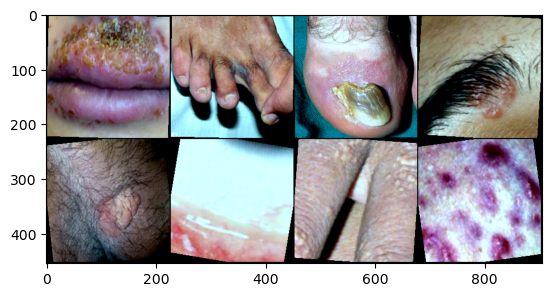

In [8]:
display_images(train_loader)

## Model

In [9]:
import torch.nn as nn
import timm

In [10]:
class SkinCancerModel(nn.Module):
    def __init__(self, num_class = 9):
        super(SkinCancerModel, self).__init__()
        self.base_model = timm.create_model("efficientnet_b0", pretrained=True)
        self.feature = nn.Sequential(*list(self.base_model.children())[:-1])

        enet_out_size = 1280
        self.classifier = nn.Linear(enet_out_size, num_class)

    def forward(self, x):
        x = self.feature(x)
        out = self.classifier(x)
        return out

In [11]:
model = SkinCancerModel()

## Training

In [12]:
import torch.optim as optim

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

loss_fn = nn.CrossEntropyLoss() # loss function
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.06) # optimizer

num_epochs = 20
train_losses, val_losses = [], []

In [13]:
for images, labels in train_loader:
    print(labels.size(0))
    break

32


In [14]:
def train_loop(train_loader, model, loss_fn, optimizer):
    size = len(train_loader.dataset)
    model.train()
    train_loss = 0.0
    for batch, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * labels.size(0)

        if batch % 50 == 0:
            loss, current = loss.item(), batch * labels.size(0) + len(images)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

    train_loss /= size
    train_losses.append(train_loss)
    return train_loss

def val_loop(val_loader, model, loss_fn):
    size = len(val_loader.dataset)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
         
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            val_loss += loss.item() * labels.size(0)

    val_loss /= size
    val_losses.append(val_loss)
    return val_loss

def test_loop(test_loader, model, loss_fn):
    size = len(test_loader.dataset)
    model.eval()
    test_loss, correct = 0.0, 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
         
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            test_loss += loss.item() * labels.size(0)
            correct += (outputs.argmax(1) == labels).type(torch.float).sum().item()

    test_loss /= size
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return test_loss, correct

In [15]:
def save_checkpoint(model, epoch, optimizer, best_acc):
    state = {
        'epoch' : epoch + 1,
        'model' : model.state_dict(),
        'best accuracy' : best_acc,
        'optimizer' : optimizer.state_dict()
    }
    torch.save(state, 'model_best_checkpoint.pth.tar')

In [16]:
checkpoint = torch.load('model_best_checkpoint.pth.tar')
best_acc = checkpoint['best accuracy']

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}\n-------------------------------")
    
    # Training
    train_loss = train_loop(train_loader, model, loss_fn, optimizer)

    # Validating
    val_loss = val_loop(val_loader, model, loss_fn)

    # Testing
    test_loss, acc = test_loop(test_loader, model, loss_fn)
    if acc > best_acc:
        best_acc = acc
        save_checkpoint(model, epoch, optimizer, best_acc)
        
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train loss: {train_loss}, Validation loss: {val_loss}, Test loss: {test_loss}\n")

Epoch 1
-------------------------------
loss: 2.287955  [   32/ 7946]
loss: 1.431880  [ 1632/ 7946]
loss: 1.149659  [ 3232/ 7946]
loss: 1.122820  [ 4832/ 7946]
loss: 0.853753  [ 6432/ 7946]
Test Error: 
 Accuracy: 69.1%, Avg loss: 1.097748 

Epoch 1/20 - Train loss: 1.3127366605946378, Validation loss: 1.1034246246475934, Test loss: 1.0977475496245102

Epoch 2
-------------------------------
loss: 1.102293  [   32/ 7946]
loss: 1.122428  [ 1632/ 7946]
loss: 0.755454  [ 3232/ 7946]
loss: 1.387463  [ 4832/ 7946]
loss: 1.482642  [ 6432/ 7946]
Test Error: 
 Accuracy: 70.1%, Avg loss: 1.019317 

Epoch 2/20 - Train loss: 1.0589964869878707, Validation loss: 1.0403580661379754, Test loss: 1.0193166965749902

Epoch 3
-------------------------------
loss: 1.215266  [   32/ 7946]
loss: 0.812264  [ 1632/ 7946]
loss: 0.688354  [ 3232/ 7946]
loss: 0.754236  [ 4832/ 7946]
loss: 0.808885  [ 6432/ 7946]
Test Error: 
 Accuracy: 70.7%, Avg loss: 0.958518 

Epoch 3/20 - Train loss: 0.9728534598210102, Val

In [17]:
# # Testing
# test_loss = test_loop(test_loader, model, loss_fn)
# print(f"Test loss: {test_loss}")

In [18]:
print(checkpoint['best accuracy'])

0.758362676056338
